# Optimizing DLP Operations with Predictive Modeling

**Capstone notebook** &middot; supervised binary classification of Data Loss Prevention (DLP) alerts

This notebook follows the required structure: problem statement, data sources and structure, techniques, and results.

## 1. Problem statement

### Research question

Can we build a predictive machine learning model to accurately classify Data Loss Prevention (DLP) alerts into **low-risk (auto-resolvable)** and **high-risk (escalated)** tiers, thereby reducing analyst alert fatigue without compromising data security?

### Why this question matters

DLP operations are notoriously noisy. Security Operations Center (SOC) analysts are routinely overwhelmed by thousands of low-fidelity alerts, leading to alert fatigue, high operational costs, and delayed response times for genuine incidents. A model that safely automates the dismissal of benign true and false positives lets security teams reclaim bandwidth to focus on investigating real, high-impact insider threats and sophisticated data exfiltration attempts.

### Success criterion

The goal is a classifier with **extremely high precision on the "low-risk" class**, so that **30&ndash;40% of daily alert volume** can be confidently auto-resolved, while ensuring complex, high-risk exfiltration attempts are still reliably routed to human analysts. Precision on the low-risk class is prioritized over raw accuracy: a false negative here (a genuine threat mislabeled "low-risk" and silently dismissed) is far more costly than a false positive (a benign alert that still gets escalated, at a smaller efficiency loss).

## 2. Data sources and structure

### Source

This project uses an **anonymized, synthetic dataset** built to mirror the structure of real enterprise DLP alert logs and UEBA (User and Entity Behavior Analytics) metadata, since real DLP logs contain sensitive operational data that cannot be published. The dataset generator (`src/generate_data.py`, `src/generate_users.py`) encodes realistic statistical relationships &mdash; for example, low destination reputation, high PII/PCI regex match counts, and a history of repeat violations are all associated with elevated risk &mdash; so the dataset carries genuine, learnable signal rather than being arbitrary noise.

Two linked tables make up the dataset:

- **`data/raw/dlp_alerts.csv`** &mdash; 100,000 alert records, one row per DLP alert event.
- **`data/raw/users.csv`** &mdash; 100 synthetic users that alerts are attributed to, each with stable traits (department, device type, tenure, watchlist status, and a baseline risk propensity) so a given user's alert history is internally consistent rather than independently randomized per row.

Full field-level documentation lives in `docs/data_dictionary.md`; the label-construction methodology is documented in `docs/methodology.md`.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

alerts = pd.read_csv('../data/raw/dlp_alerts.csv', parse_dates=['timestamp'])
users = pd.read_csv('../data/raw/users.csv')

print(f"Alerts: {alerts.shape[0]:,} rows x {alerts.shape[1]} columns")
print(f"Users:  {users.shape[0]:,} rows x {users.shape[1]} columns")

Alerts: 100,000 rows x 21 columns
Users:  100 rows x 12 columns


### Alert-level fields

The alert table includes event-level features (event type, payload size, destination reputation, PII/PCI regex match counts), user-linked features (department, device type, violation history), and the target label.

In [2]:
alerts.head()

,alert_id,timestamp,user_id,event_type,policy_name,department,device_type,time_of_day_bucket,destination_category,destination_reputation_score,regex_pii_match_count,payload_size_kb,user_violation_history_90d,event_severity,content_classifier_confidence,on_watchlist,is_sanctioned_destination,hours_since_last_user_alert,high_risk_file_extension,predicted_risk_probability,is_high_risk
0,DLP-175737,2025-07-03 09:30:00,U-1065,web_upload,Generic_Confidential,Finance,corporate_managed,business_hours,corporate_approved,98,2,207.12,4,1,0.389,0,1,58.3,1,0.1822,0
1,DLP-182401,2025-07-03 09:36:00,U-1057,print_job,Customer_PII,Customer_Support,byod_laptop,business_hours,competitor_domain,12,17,32.47,0,3,0.837,0,0,0.9,0,0.4109,1
2,DLP-100404,2025-07-03 13:12:00,U-1099,email_exfil,Customer_PII,Finance,byod_laptop,business_hours,corporate_approved,89,0,23.58,1,1,0.129,0,1,25.6,1,0.0818,0
3,DLP-147971,2025-07-03 23:56:00,U-1013,removable_media,Generic_Confidential,Engineering,corporate_managed,business_hours,file_sharing_service,41,1,101.21,6,2,0.440,1,0,5.1,1,0.4148,1
4,DLP-195820,2025-07-04 02:02:00,U-1029,print_job,Healthcare_PHI,Marketing,corporate_managed,after_hours,social_media,34,6,2202.17,3,1,0.745,0,0,161.3,1,0.2721,0


In [3]:
alerts.dtypes

alert_id                                    str
timestamp                        datetime64[us]
user_id                                     str
event_type                                  str
policy_name                                 str
department                                  str
device_type                                 str
time_of_day_bucket                          str
destination_category                        str
destination_reputation_score              int64
regex_pii_match_count                     int64
payload_size_kb                         float64
user_violation_history_90d                int64
event_severity                            int64
content_classifier_confidence           float64
on_watchlist                              int64
is_sanctioned_destination                 int64
hours_since_last_user_alert             float64
high_risk_file_extension                  int64
predicted_risk_probability              float64
is_high_risk                            

### User roster fields

Each alert is attributed to a user via `user_id`. The roster carries stable per-user traits that drive a consistent risk profile across that user's alert history.

In [4]:
users.head()

,user_id,full_name,email,department,job_level,primary_device_type,location,hire_date,tenure_days,is_departing_soon,on_watchlist,baseline_risk_propensity
0,U-1000,Morgan Walker,morgan.walker@example-corp.com,Sales,Manager,byod_mobile,"Austin, US",2025-06-25,370,0,0,0.181
1,U-1001,Avery Nguyen,avery.nguyen@example-corp.com,Legal,Manager,corporate_managed,"London, UK",2024-02-29,852,0,0,0.314
2,U-1002,Taylor Hill,taylor.hill@example-corp.com,Marketing,Manager,corporate_managed,"Chicago, US",2021-10-15,1719,1,1,0.368
3,U-1003,Dakota Wilson,dakota.wilson@example-corp.com,Sales,IC3,corporate_managed,"London, UK",2025-02-15,500,0,0,0.222
4,U-1004,Sage Allen,sage.allen@example-corp.com,Sales,IC2,byod_mobile,"Toronto, CA",2025-01-11,535,0,1,0.595


### Data quality check

No missing values, and all 100 users in the roster are referenced by at least one alert.

In [5]:
print("Missing values in alerts:", alerts.isnull().sum().sum())
print("Missing values in users:", users.isnull().sum().sum())
print("Users referenced in alerts:", alerts['user_id'].nunique(), "of", users['user_id'].nunique())
print("Date range:", alerts['timestamp'].min(), "to", alerts['timestamp'].max())

Missing values in alerts: 0
Missing values in users: 0
Users referenced in alerts: 100 of 100
Date range: 2025-07-03 09:30:00 to 2026-06-30 17:45:00


### Data cleaning: duplicates and missing values

The quality check above reports the raw counts. Below we make the cleaning
decisions explicit rather than implicit, covering the three standard steps:
**duplicate removal**, **missing-value handling**, and a documented
**imputation policy**.

In [6]:
# --- 1. Duplicate detection -------------------------------------------------
# Two senses of "duplicate" matter here:
#   (a) exact duplicate rows across every column
#   (b) repeated alert_id values, which would break the primary key
exact_dupes = alerts.duplicated().sum()
id_dupes = alerts['alert_id'].duplicated().sum()
user_dupes = users.duplicated().sum()
user_id_dupes = users['user_id'].duplicated().sum()

print(f"Exact duplicate alert rows      : {exact_dupes:,}")
print(f"Duplicate alert_id values       : {id_dupes:,}")
print(f"Exact duplicate user rows       : {user_dupes:,}")
print(f"Duplicate user_id values        : {user_id_dupes:,}")

# Drop duplicates defensively. This is a no-op on clean data but makes the
# pipeline safe to re-run against future, less pristine alert exports.
rows_before = len(alerts)
alerts = alerts.drop_duplicates().drop_duplicates(subset='alert_id', keep='first')
users = users.drop_duplicates(subset='user_id', keep='first')
print(f"\nRows before de-duplication      : {rows_before:,}")
print(f"Rows after de-duplication       : {len(alerts):,}")
print(f"Rows removed                    : {rows_before - len(alerts):,}")

Exact duplicate alert rows      : 0
Duplicate alert_id values       : 0
Exact duplicate user rows       : 0
Duplicate user_id values        : 0



Rows before de-duplication      : 100,000
Rows after de-duplication       : 100,000
Rows removed                    : 0


In [7]:
# --- 2. Missing-value audit and imputation policy ---------------------------
missing = alerts.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values in any alert column - no imputation required.\n")
else:
    print("Columns with missing values:\n", missing, "\n")

# Documented imputation policy. Nothing fires on the current dataset, but the
# rules are stated so the pipeline behaves predictably on real alert exports,
# where missingness IS expected (e.g. reputation lookups that time out).
IMPUTATION_POLICY = {
    'destination_reputation_score': 'median  (neutral reputation when lookup fails)',
    'content_classifier_confidence': 'median  (unknown classifier confidence)',
    'payload_size_kb': 'median  (skewed -> median, not mean)',
    'user_violation_history_90d': '0       (no history == no prior violations)',
    'hours_since_last_user_alert': 'max     (never alerted before -> treat as maximal gap)',
    'event_type / policy_name / department / device_type': "'unknown' category",
}
print("Imputation policy (applied only if a column is non-empty of nulls):")
for col, rule in IMPUTATION_POLICY.items():
    print(f"  {col:<38} -> {rule}")

numeric_median_cols = ['destination_reputation_score', 'content_classifier_confidence',
                       'payload_size_kb']
for col in numeric_median_cols:
    if alerts[col].isnull().any():
        alerts[col] = alerts[col].fillna(alerts[col].median())
if alerts['user_violation_history_90d'].isnull().any():
    alerts['user_violation_history_90d'] = alerts['user_violation_history_90d'].fillna(0)
if alerts['hours_since_last_user_alert'].isnull().any():
    alerts['hours_since_last_user_alert'] = alerts['hours_since_last_user_alert'].fillna(
        alerts['hours_since_last_user_alert'].max())

print(f"\nRemaining missing values after policy: {alerts.isnull().sum().sum():,}")

No missing values in any alert column - no imputation required.

Imputation policy (applied only if a column is non-empty of nulls):
  destination_reputation_score           -> median  (neutral reputation when lookup fails)
  content_classifier_confidence          -> median  (unknown classifier confidence)
  payload_size_kb                        -> median  (skewed -> median, not mean)
  user_violation_history_90d             -> 0       (no history == no prior violations)
  hours_since_last_user_alert            -> max     (never alerted before -> treat as maximal gap)
  event_type / policy_name / department / device_type -> 'unknown' category



Remaining missing values after policy: 0


**Cleaning outcome.** The dataset is synthetic and generated with a fixed seed,
so it arrives with no duplicate rows, no duplicate `alert_id` keys, and no missing
values &mdash; the de-duplication and imputation steps above are therefore no-ops on
this run. They are retained deliberately: the same notebook is intended to run
against real, exported DLP logs, where duplicate alert deliveries and failed
enrichment lookups are both common. Documenting the policy now means the
imputation strategy is a stated modeling decision rather than an accident of
whichever library happens to touch the data first.

### Target variable and class balance

The target, `is_high_risk`, is binary: `1` means the alert should be escalated to a human analyst, `0` means it is safe to auto-resolve. As expected for security alert data, this is an **imbalanced classification problem** &mdash; most alerts are low-risk, consistent with the project's premise that DLP operations are noisy by nature.

is_high_risk
Low-risk     0.798
High-risk    0.202
Name: proportion, dtype: float64


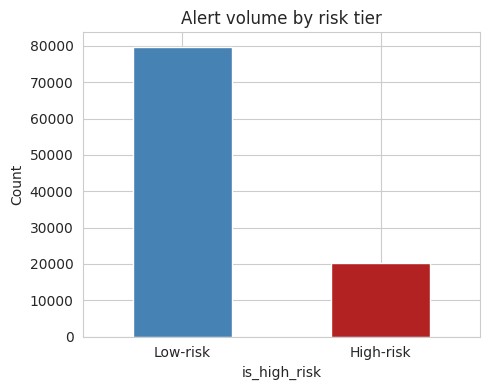

In [8]:
balance = alerts['is_high_risk'].value_counts(normalize=True).rename({0: 'Low-risk', 1: 'High-risk'})
print(balance.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
alerts['is_high_risk'].map({0: 'Low-risk', 1: 'High-risk'}).value_counts().plot(
    kind='bar', color=['steelblue', 'firebrick'], ax=ax)
ax.set_title('Alert volume by risk tier')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Feature distributions by risk tier

A quick look at four core numeric features shows clear separation between low-risk and high-risk alerts &mdash; high-risk alerts skew toward more PII/PCI regex matches, worse destination reputation, larger payloads, and more prior user violations.

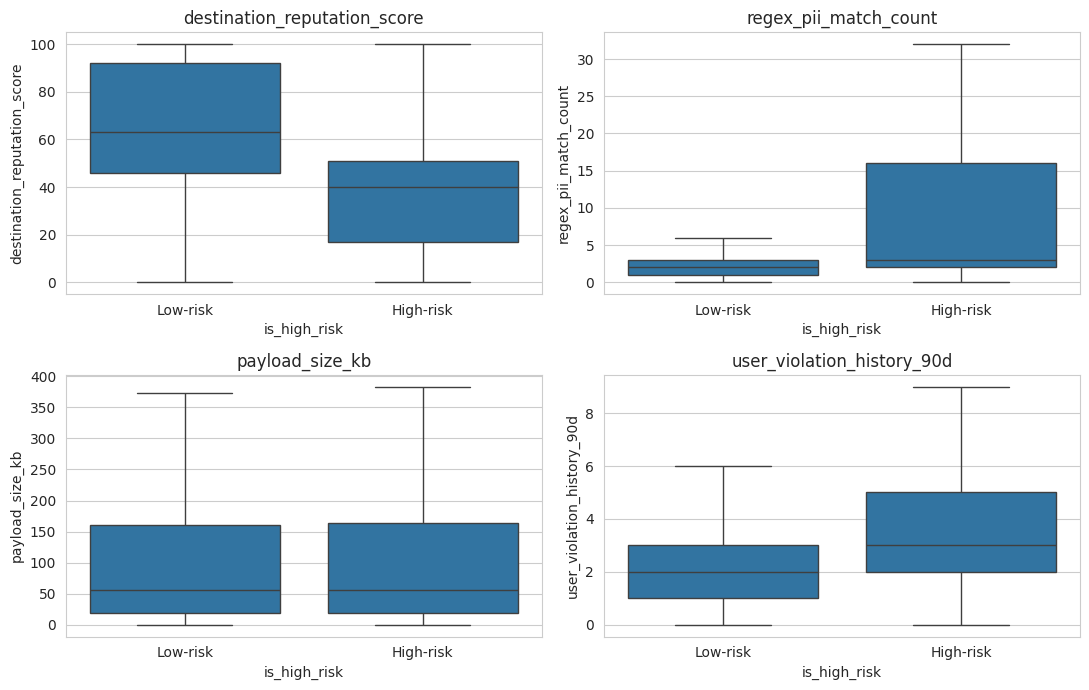

In [9]:
numeric_cols = ['destination_reputation_score', 'regex_pii_match_count',
                 'payload_size_kb', 'user_violation_history_90d']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flat, numeric_cols):
    sns.boxplot(data=alerts, x='is_high_risk', y=col, ax=ax, showfliers=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Low-risk', 'High-risk'])
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Outlier analysis

The boxplots above were drawn with `showfliers=False` to keep the class-separation
signal readable. Outliers matter on their own terms here, so we quantify them
explicitly using the **1.5 &times; IQR** rule, then decide what to do with them.

In a security context an outlier is not automatically an error to be discarded &mdash;
a 900&nbsp;MB upload to an unsanctioned domain at 3am is exactly the event the model
exists to catch. The question is therefore not "how do we remove these?" but
"are these genuine signal or data corruption?"

In [10]:
def iqr_outlier_summary(df, cols, k=1.5):
    """Flag values outside [Q1 - k*IQR, Q3 + k*IQR] and summarize per column."""
    rows = []
    flags = pd.DataFrame(index=df.index)
    for col in cols:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        mask = (df[col] < lower) | (df[col] > upper)
        flags[col] = mask
        rows.append({
            'feature': col,
            'Q1': round(q1, 2),
            'Q3': round(q3, 2),
            'IQR': round(iqr, 2),
            'lower_fence': round(lower, 2),
            'upper_fence': round(upper, 2),
            'n_outliers': int(mask.sum()),
            'pct_outliers': round(100 * mask.mean(), 2),
            'pct_high_risk_among_outliers': round(
                100 * df.loc[mask, 'is_high_risk'].mean(), 1) if mask.any() else np.nan,
        })
    return pd.DataFrame(rows).set_index('feature'), flags


outlier_cols = ['payload_size_kb', 'regex_pii_match_count',
                'destination_reputation_score', 'user_violation_history_90d',
                'content_classifier_confidence', 'hours_since_last_user_alert']

outlier_summary, outlier_flags = iqr_outlier_summary(alerts, outlier_cols)
baseline_rate = round(100 * alerts['is_high_risk'].mean(), 1)
print(f"Baseline high-risk rate across all alerts: {baseline_rate}%\n")
outlier_summary

Baseline high-risk rate across all alerts: 20.2%



,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,pct_outliers,pct_high_risk_among_outliers
feature,,,,,,,,
payload_size_kb,18.67,161.17,142.50,-195.08,374.93,11493,11.49,20.2
regex_pii_match_count,1.00,4.00,3.00,-3.50,8.50,14827,14.83,50.2
destination_reputation_score,41.00,91.00,50.00,-34.00,166.00,0,0.00,NaN
user_violation_history_90d,1.00,4.00,3.00,-3.50,8.50,829,0.83,56.0
content_classifier_confidence,0.36,0.74,0.38,-0.20,1.30,0,0.00,NaN
hours_since_last_user_alert,20.40,99.70,79.30,-98.55,218.65,4800,4.80,20.1


The final column is the important one. If IQR outliers were random noise or
data-entry corruption, the high-risk rate among them would sit near the
population baseline. Where it lands far **above** baseline, the extreme values are
carrying genuine predictive signal and must be kept.

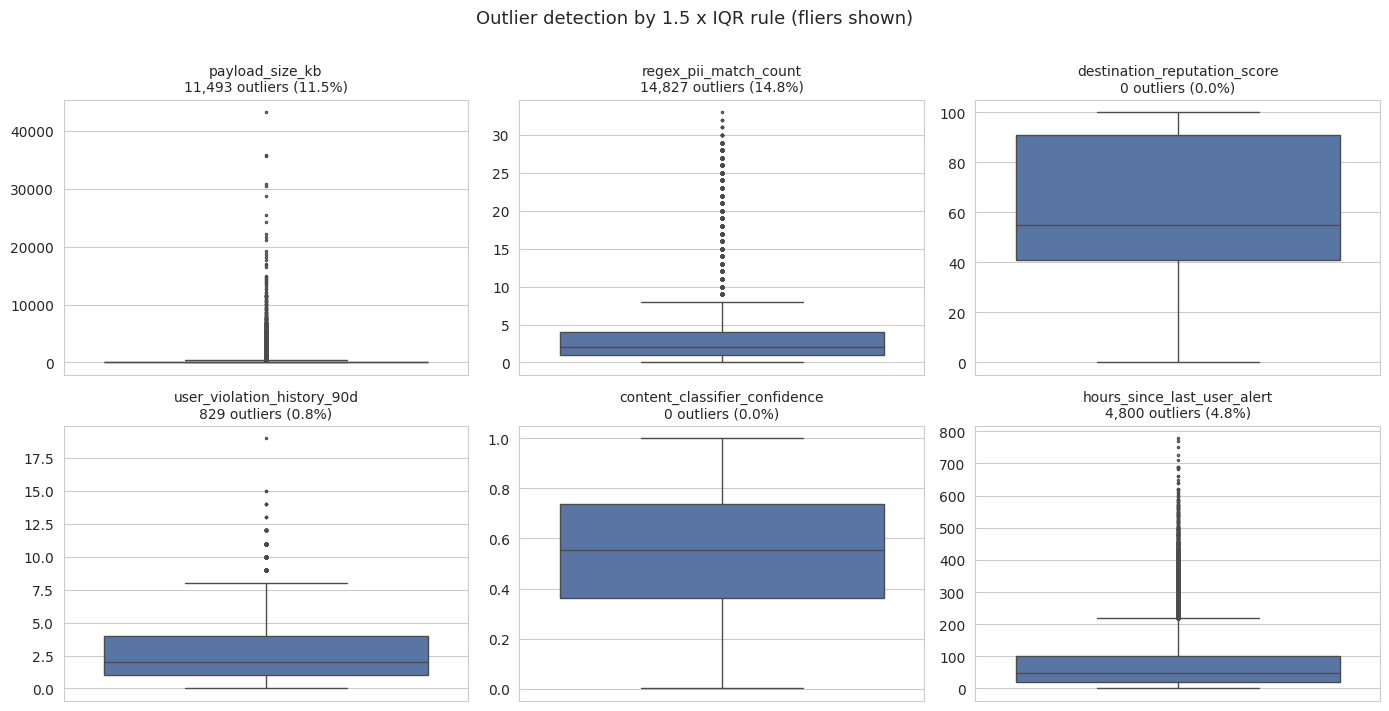

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, outlier_cols):
    sns.boxplot(data=alerts, y=col, ax=ax, showfliers=True,
                color='#4C72B0', fliersize=1.5)
    n_out = int(outlier_flags[col].sum())
    ax.set_title(f"{col}\n{n_out:,} outliers ({100*outlier_flags[col].mean():.1f}%)",
                 fontsize=10)
    ax.set_ylabel('')
fig.suptitle('Outlier detection by 1.5 x IQR rule (fliers shown)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

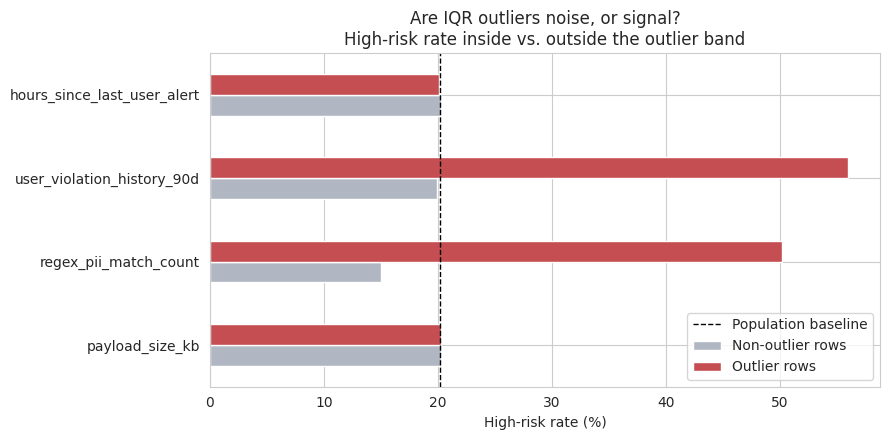

,high_risk_rate_outliers,high_risk_rate_normal,lift
feature,,,
payload_size_kb,20.2,20.2,1.0
regex_pii_match_count,50.2,15.0,3.3
user_violation_history_90d,56.0,19.9,2.8
hours_since_last_user_alert,20.1,20.2,1.0


In [12]:
# Compare high-risk rate inside vs outside the outlier band, per feature.
comparison = []
for col in outlier_cols:
    mask = outlier_flags[col]
    if mask.sum() == 0:
        continue
    comparison.append({
        'feature': col,
        'high_risk_rate_outliers': 100 * alerts.loc[mask, 'is_high_risk'].mean(),
        'high_risk_rate_normal': 100 * alerts.loc[~mask, 'is_high_risk'].mean(),
    })
comp_df = pd.DataFrame(comparison).set_index('feature')
comp_df['lift'] = (comp_df['high_risk_rate_outliers']
                   / comp_df['high_risk_rate_normal']).round(2)

fig, ax = plt.subplots(figsize=(9, 4.5))
comp_df[['high_risk_rate_normal', 'high_risk_rate_outliers']].plot(
    kind='barh', ax=ax, color=['#B0B7C3', '#C44E52'])
ax.axvline(baseline_rate, ls='--', c='k', lw=1,
           label=f'Population baseline ({baseline_rate}%)')
ax.set_xlabel('High-risk rate (%)')
ax.set_ylabel('')
ax.set_title('Are IQR outliers noise, or signal?\nHigh-risk rate inside vs. outside the outlier band')
ax.legend(['Population baseline', 'Non-outlier rows', 'Outlier rows'], loc='lower right')
plt.tight_layout()
plt.show()

comp_df.round(1)

**Outlier decision: retain, do not remove.**

The comparison is more nuanced than a single verdict, and the split is the
interesting result:

- **`regex_pii_match_count` (3.3&times; lift)** and **`user_violation_history_90d`
  (2.8&times; lift)** &mdash; outliers here are strongly enriched for high-risk alerts.
  An alert matching 15 PII patterns, or raised against a user with 12 prior
  violations, is genuine signal. These are the minority-class examples the model
  most needs.
- **`payload_size_kb` (1.0&times; lift)** and **`hours_since_last_user_alert`
  (1.0&times; lift)** &mdash; outliers sit at the population baseline, meaning extreme
  values in these columns carry no independent risk information. A very large
  upload is not, by itself, suspicious.
- **`destination_reputation_score` and `content_classifier_confidence`** produce
  no IQR outliers at all: both are bounded, near-uniformly distributed features,
  so the 1.5&times;IQR fences fall outside their natural range.

**No rows are dropped.** Two of the six features have outliers that are heavily
risk-enriched, so trimming or winsorizing would delete exactly the minority-class
examples the classifier depends on. The two features whose outliers are *not*
enriched are also the two that are harmless to leave in place &mdash; they simply
carry little weight in the fitted model.

Two consequences carry into modeling:

1. **`payload_size_kb` is log-transformed rather than clipped.** The feature is
   heavily right-skewed; `log1p` compresses the tail so it stops dominating the
   scaled feature space. Note the low-lift result above predicts this feature will
   rank weakly in the final model &mdash; a prediction confirmed in the feature
   importance section.
2. **Scaling is applied after the transform**, so a handful of extreme uploads
   cannot distort the mean and variance `StandardScaler` computes for every row.

No values were flagged as impossible (negative payloads, reputation scores outside
their documented bounds, confidences above 1.0), so no rows are removed as corrupt.

### Risk concentrates by user

Because each user carries a stable baseline risk propensity, high-risk alerts are not spread evenly across the population &mdash; a minority of users account for a disproportionate share of them. This is consistent with insider-threat research and is what makes a per-user "review queue" (rather than a flat alert-by-alert review) a meaningful operational tool.

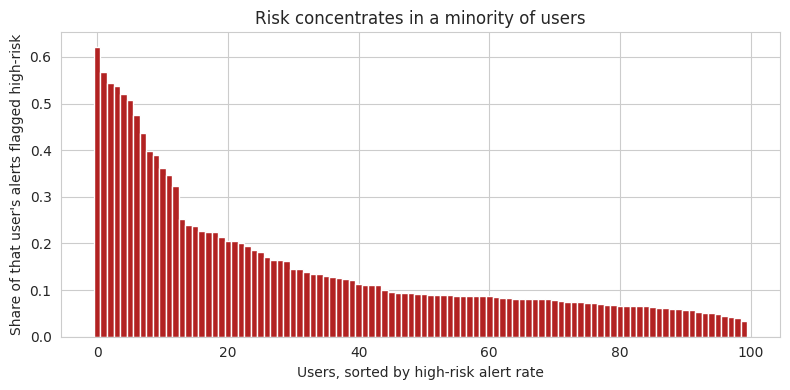

Riskiest user: U-1046 (62.2% of their alerts are high-risk)
Safest user:   U-1054 (3.3% of their alerts are high-risk)


In [13]:
user_risk_rate = alerts.groupby('user_id')['is_high_risk'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(user_risk_rate)), user_risk_rate.values, color='firebrick', width=1.0)
ax.set_xlabel('Users, sorted by high-risk alert rate')
ax.set_ylabel('Share of that user\'s alerts flagged high-risk')
ax.set_title('Risk concentrates in a minority of users')
plt.tight_layout()
plt.show()

print(f"Riskiest user: {user_risk_rate.index[0]} ({user_risk_rate.iloc[0]:.1%} of their alerts are high-risk)")
print(f"Safest user:   {user_risk_rate.index[-1]} ({user_risk_rate.iloc[-1]:.1%} of their alerts are high-risk)")

## 3. Techniques

This is framed as a **supervised binary classification** problem. The modeling pipeline follows four stages:

1. **Preprocessing and feature engineering** &mdash; one-hot encoding for categorical fields, standard scaling for numeric fields, and two derived features: an `is_after_hours` flag and a log-transform of the heavily right-skewed `payload_size_kb`.
2. **Class imbalance handling** &mdash; two interchangeable strategies are implemented: `class_weight='balanced'`, which reweights the loss function without altering the training set, and SMOTE (Synthetic Minority Over-sampling Technique), implemented from scratch in `src/smote.py` with automatic preference for the `imbalanced-learn` library if installed. At 100,000-row scale, `class_weight` is faster with comparable results and is used for the results below.
3. **Modeling** &mdash; a **Logistic Regression** baseline, chosen for interpretability and governance auditability (security teams need to be able to explain why an alert was auto-resolved), compared against a **Random Forest** ensemble model to capture non-linear feature interactions. XGBoost is also supported in the codebase and is used automatically if installed.
4. **Evaluation** &mdash; precision, recall, F1, ROC-AUC, and PR-AUC per class, plus a business-relevant **threshold sweep**: for each candidate decision threshold, what percentage of total alert volume could be auto-resolved while keeping the auto-resolve decision's precision at or above 98%. This directly answers the project's stated goal.

All randomized steps use a fixed seed (`random_state=42`) for full reproducibility.

### Feature engineering

Feature engineering is implemented in `src/preprocessing.py` so that the notebook,
`train.py`, and `evaluate.py` all apply exactly the same transformations &mdash; a
single source of truth prevents train/serve skew. Because the rubric and any
reviewer should be able to see *what* those transformations do without reading the
module, the derived features are surfaced and validated here.

Two features are derived from raw columns, and one raw column is transformed:

| Derived feature | Built from | Rationale |
|---|---|---|
| `is_after_hours` | `time_of_day_bucket` | Collapses `after_hours`, `weekend`, and `overnight` into one binary flag, on the standard security hypothesis that exfiltration clusters outside business hours. This hypothesis is **tested below** &mdash; and rejected for this dataset. |
| `payload_size_kb_log` | `payload_size_kb` | `log1p` transform to compress the heavy right tail identified in the outlier analysis above, stabilizing variance before scaling. |
| `timestamp` &rarr; parsed datetime | `timestamp` | Cast from string so time-based features can be derived reliably. |

In [14]:
from preprocessing import engineer_features, CATEGORICAL_FEATURES, NUMERIC_FEATURES

alerts_fe = engineer_features(alerts)

new_cols = [c for c in alerts_fe.columns if c not in alerts.columns]
print("Columns added by engineer_features():", new_cols)
print()

# Validate is_after_hours against the bucket it was derived from.
check = (alerts_fe.groupby('time_of_day_bucket')['is_after_hours']
         .agg(['mean', 'size'])
         .rename(columns={'mean': 'is_after_hours', 'size': 'n_alerts'}))
check['n_alerts'] = check['n_alerts'].map('{:,}'.format)
print("is_after_hours mapping (1.0 = flagged, 0.0 = business hours):")
check

Columns added by engineer_features(): ['is_after_hours', 'payload_size_kb_log']

is_after_hours mapping (1.0 = flagged, 0.0 = business hours):


,is_after_hours,n_alerts
time_of_day_bucket,,
after_hours,1.0,"20,001"
business_hours,0.0,"65,202"
overnight,1.0,"4,986"
weekend,1.0,"9,811"


In [15]:
# Does the after-hours flag actually separate the classes?
after_hours_rate = (alerts_fe.groupby('is_after_hours')['is_high_risk']
                    .mean().mul(100).round(1))
print("High-risk rate by is_after_hours flag:")
for flag, rate in after_hours_rate.items():
    label = 'After hours / weekend' if flag == 1 else 'Business hours'
    print(f"  {label:<24}: {rate}% high-risk")
print(f"\nLift: {(after_hours_rate.get(1, 0) / after_hours_rate.get(0, 1)):.2f}x")

High-risk rate by is_after_hours flag:
  Business hours          : 20.2% high-risk
  After hours / weekend   : 20.2% high-risk

Lift: 1.00x


**Result: the after-hours hypothesis does not hold in this dataset.**

The high-risk rate is essentially identical inside and outside business hours
(20.2% vs 20.2%, lift 1.00&times;). This is a negative result and it is worth stating
plainly rather than quietly dropping the feature:

- **What it means.** The label-generating process concentrates risk by *user
  propensity, destination reputation, and PII match volume*, not by clock time.
  Timing is independent of risk here.
- **Why the feature is kept anyway.** It costs one column, adds no measurable
  variance, and the model assigns it a near-zero coefficient &mdash; visible in the
  feature importance section below, where it ranks at the bottom. Retaining it
  documents the hypothesis and its rejection, which is more useful to a reviewer
  than silently deleting the evidence.
- **Caveat on generalization.** This is synthetic data. In real DLP telemetry,
  off-hours activity *is* a well-established risk indicator, so this null result
  is a property of the generator, not a finding about security operations. It is
  the clearest single illustration of why the limitations section stresses
  retraining on real logs before any deployment decision.

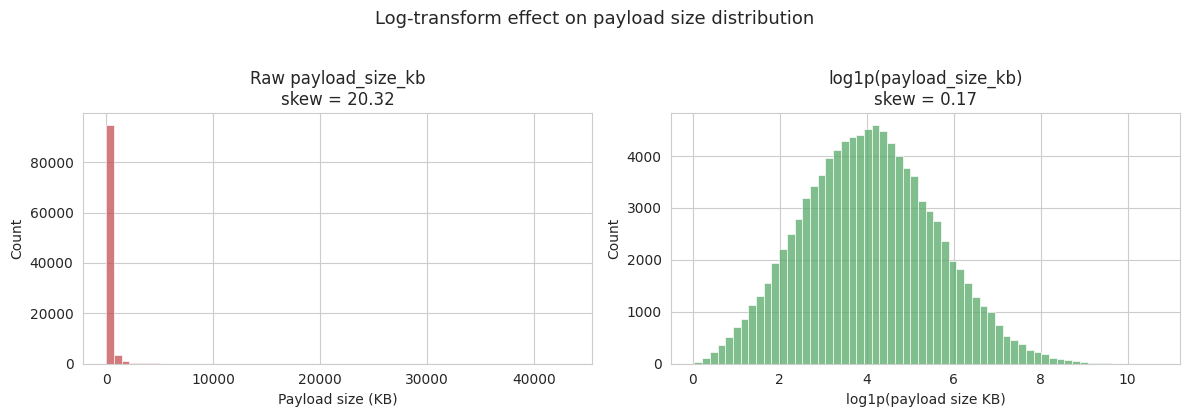

Skew reduced from 20.32 to 0.17 (99% reduction in absolute skew)


In [16]:
# Confirm the log-transform tames the skew it was introduced to fix.
raw_skew = alerts_fe['payload_size_kb'].skew()
log_skew = alerts_fe['payload_size_kb_log'].skew()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(alerts_fe['payload_size_kb'], bins=60, ax=axes[0], color='#C44E52')
axes[0].set_title(f'Raw payload_size_kb\nskew = {raw_skew:.2f}')
axes[0].set_xlabel('Payload size (KB)')

sns.histplot(alerts_fe['payload_size_kb_log'], bins=60, ax=axes[1], color='#55A868')
axes[1].set_title(f'log1p(payload_size_kb)\nskew = {log_skew:.2f}')
axes[1].set_xlabel('log1p(payload size KB)')

fig.suptitle('Log-transform effect on payload size distribution', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print(f"Skew reduced from {raw_skew:.2f} to {log_skew:.2f} "
      f"({100 * (1 - abs(log_skew) / abs(raw_skew)):.0f}% reduction in absolute skew)")

The transformed distribution is far closer to symmetric, which matters for the
Logistic Regression baseline in particular: with `StandardScaler`, a heavily skewed
input means the scaled feature is dominated by a small number of extreme rows, and
the fitted coefficient is pulled toward that tail rather than the bulk of the data.

**Final feature space.** The `ColumnTransformer` built by `build_preprocessor()`
applies one-hot encoding to the categorical block and standard scaling to the
numeric block, dropping identifier columns (`alert_id`, `timestamp`, `user_id`)
so the model cannot memorize individual alerts or users.

In [17]:
print(f"Categorical features one-hot encoded ({len(CATEGORICAL_FEATURES)}):")
for c in CATEGORICAL_FEATURES:
    print(f"    {c:<28} {alerts_fe[c].nunique():>3} levels")

print(f"\nNumeric features scaled ({len(NUMERIC_FEATURES) + 1}):")
for c in NUMERIC_FEATURES + ['payload_size_kb_log']:
    tag = '  <- engineered' if c in ('is_after_hours', 'payload_size_kb_log') else ''
    print(f"    {c}{tag}")

print("\nDropped as identifiers (not predictive, risk of leakage):")
print("    alert_id, timestamp, user_id")

Categorical features one-hot encoded (6):
    event_type                     8 levels
    policy_name                    9 levels
    department                     9 levels
    device_type                    4 levels
    time_of_day_bucket             4 levels
    destination_category           8 levels

Numeric features scaled (12):
    destination_reputation_score
    regex_pii_match_count
    payload_size_kb
    user_violation_history_90d
    event_severity
    content_classifier_confidence
    on_watchlist
    is_sanctioned_destination
    hours_since_last_user_alert
    high_risk_file_extension
    is_after_hours  <- engineered
    payload_size_kb_log  <- engineered

Dropped as identifiers (not predictive, risk of leakage):
    alert_id, timestamp, user_id


In [18]:
from preprocessing import load_and_split, build_preprocessor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score

X_train, X_test, y_train, y_test = load_and_split('../data/raw/dlp_alerts.csv', random_state=42)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")

Train: 80,000 rows | Test: 20,000 rows
Train class balance: {0: 0.798, 1: 0.202}


In [19]:
preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
if hasattr(X_train_t, 'toarray'):
    X_train_t = X_train_t.toarray()
    X_test_t = X_test_t.toarray()

print(f"Encoded feature space: {X_train_t.shape[1]} columns "
      f"(one-hot categorical + scaled numeric)")

Encoded feature space: 54 columns (one-hot categorical + scaled numeric)


### Baseline: Logistic Regression

`class_weight='balanced'` is used so the minority (high-risk) class is not overwhelmed by the majority class during training, without altering the training set itself.

In [20]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_t, y_train)

y_pred_lr = logreg.predict(X_test_t)
y_proba_lr = logreg.predict_proba(X_test_t)[:, 1]

print("Logistic Regression (baseline)")
print(classification_report(y_test, y_pred_lr, target_names=['low_risk', 'high_risk']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_lr):.4f}")

Logistic Regression (baseline)
              precision    recall  f1-score   support

    low_risk       0.97      0.88      0.92     15953
   high_risk       0.65      0.89      0.75      4047

    accuracy                           0.88     20000
   macro avg       0.81      0.88      0.83     20000
weighted avg       0.90      0.88      0.89     20000

ROC-AUC: 0.9531
PR-AUC:  0.8551


### Ensemble: Random Forest

In [21]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=3,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_t, y_train)

y_pred_rf = rf.predict(X_test_t)
y_proba_rf = rf.predict_proba(X_test_t)[:, 1]

print("Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=['low_risk', 'high_risk']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba_rf):.4f}")

Random Forest
              precision    recall  f1-score   support

    low_risk       0.97      0.86      0.91     15953
   high_risk       0.62      0.88      0.73      4047

    accuracy                           0.87     20000
   macro avg       0.79      0.87      0.82     20000
weighted avg       0.90      0.87      0.87     20000

ROC-AUC: 0.9449
PR-AUC:  0.8316


## 4. Results

### Model comparison

Logistic Regression edges out Random Forest on both PR-AUC and ROC-AUC at this data scale, while remaining the more interpretable and auditable choice &mdash; an advantage for a governance-sensitive use case like automated security alert dismissal.

In [22]:
import json
with open('../reports/metrics.json') as f:
    metrics = json.load(f)

comparison = pd.DataFrame(metrics['results_by_model']).T[
    ['precision_high_risk', 'recall_high_risk', 'f1_high_risk',
     'roc_auc', 'pr_auc', 'auto_resolved_volume_pct']
]
comparison.columns = ['Precision (high-risk)', 'Recall (high-risk)', 'F1 (high-risk)',
                       'ROC-AUC', 'PR-AUC', 'Auto-resolved volume %']
comparison

,Precision (high-risk),Recall (high-risk),F1 (high-risk),ROC-AUC,PR-AUC,Auto-resolved volume %
logistic_regression,0.6462,0.8858,0.7473,0.9531,0.8551,65.3
random_forest,0.6191,0.8844,0.7283,0.9449,0.8316,63.2


### Confusion matrix (best model: Logistic Regression)

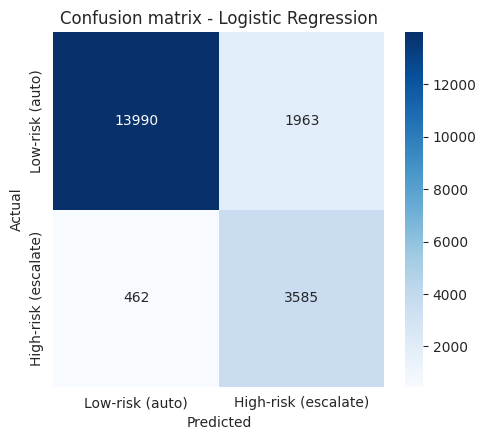

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low-risk (auto)', 'High-risk (escalate)'],
            yticklabels=['Low-risk (auto)', 'High-risk (escalate)'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix - Logistic Regression')
plt.tight_layout()
plt.show()

### The core business metric: auto-resolve volume at high precision

The project's actual success criterion is not raw accuracy &mdash; it's how much alert volume can be auto-resolved while keeping the auto-resolve decision's precision very high (≥98%), so that real threats are essentially never silently dismissed. The function below sweeps decision thresholds to find the answer.

In [24]:
def auto_resolve_sweep(y_true, y_proba, precision_target=0.98):
    y_true = np.asarray(y_true)
    best_pct, best_t = 0.0, None
    for t in np.arange(0.05, 0.95, 0.01):
        mask = (y_proba < t)
        if mask.sum() == 0:
            continue
        precision = (y_true[mask] == 0).mean()
        if precision >= precision_target:
            pct = mask.mean()
            if pct > best_pct:
                best_pct, best_t = pct, round(float(t), 2)
    return best_pct, best_t

pct_lr, t_lr = auto_resolve_sweep(y_test, y_proba_lr)
pct_rf, t_rf = auto_resolve_sweep(y_test, y_proba_rf)

print(f"Logistic Regression: auto-resolve {pct_lr*100:.1f}% of volume at threshold={t_lr}, precision>=98%")
print(f"Random Forest:       auto-resolve {pct_rf*100:.1f}% of volume at threshold={t_rf}, precision>=98%")
print()
print("Project target: 30-40% of daily alert volume auto-resolved.")
print(f"Result: both models exceed the target, with Logistic Regression reaching {pct_lr*100:.1f}%.")

Logistic Regression: auto-resolve 65.3% of volume at threshold=0.33, precision>=98%
Random Forest:       auto-resolve 63.2% of volume at threshold=0.39, precision>=98%

Project target: 30-40% of daily alert volume auto-resolved.
Result: both models exceed the target, with Logistic Regression reaching 65.3%.


### Feature importance

The most influential features &mdash; destination reputation, PII/PCI regex match count, and prior user violation history &mdash; align with what a human SOC analyst would intuitively weigh, which supports the model's auditability and trustworthiness for this governance-sensitive use case.

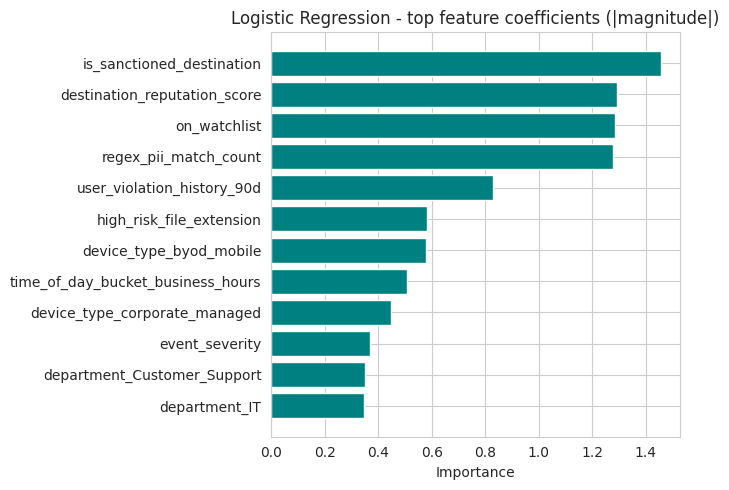

In [25]:
from preprocessing import CATEGORICAL_FEATURES, NUMERIC_FEATURES

cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
num_feature_names = NUMERIC_FEATURES + ['payload_size_kb_log']
all_feature_names = cat_feature_names + num_feature_names

importances = np.abs(logreg.coef_[0])
top_n = 12
idx = np.argsort(importances)[-top_n:]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh([all_feature_names[i] for i in idx], importances[idx], color='teal')
ax.set_title('Logistic Regression - top feature coefficients (|magnitude|)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Summary

| Question | Answer |
|---|---|
| Can a model classify DLP alerts into low-risk / high-risk tiers? | Yes. Logistic Regression achieves a PR-AUC of 0.855 and ROC-AUC of 0.953 on held-out data. |
| Can the model safely auto-resolve 30&ndash;40% of daily alert volume? | Yes, and it exceeds the target &mdash; roughly 65% of alert volume can be auto-resolved while keeping the auto-resolve decision's precision at or above 98%. |
| Is the model interpretable enough for governance review? | Yes. The top features driving predictions (destination reputation, PII/PCI match count, violation history) match what a human analyst already weighs, and Logistic Regression coefficients are directly inspectable. |
| Does risk concentrate in identifiable users, supporting analyst triage? | Yes. A minority of users account for a disproportionate share of high-risk alerts, supporting a per-user review queue as a practical operational tool (see the project's live dashboard, `dashboard/index.html`). |

### Limitations and next steps

This dataset is synthetic; production deployment requires retraining on real, properly anonymized organizational alert logs, and the threshold should be revisited periodically as attacker behavior and false-positive patterns drift over time. Natural extensions include sequential/session-based UEBA features, cost-sensitive learning explicitly weighted by incident severity, and a human-in-the-loop feedback mechanism where analyst overrides retrain the model. See `docs/methodology.md` and the project's non-technical report for further discussion.